In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

from sklearn.manifold import TSNE
import numpy as np
import matplotlib.pyplot as plt

# Set random seed for reproducibility
torch.manual_seed(42)

# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Denoising Autoencoder

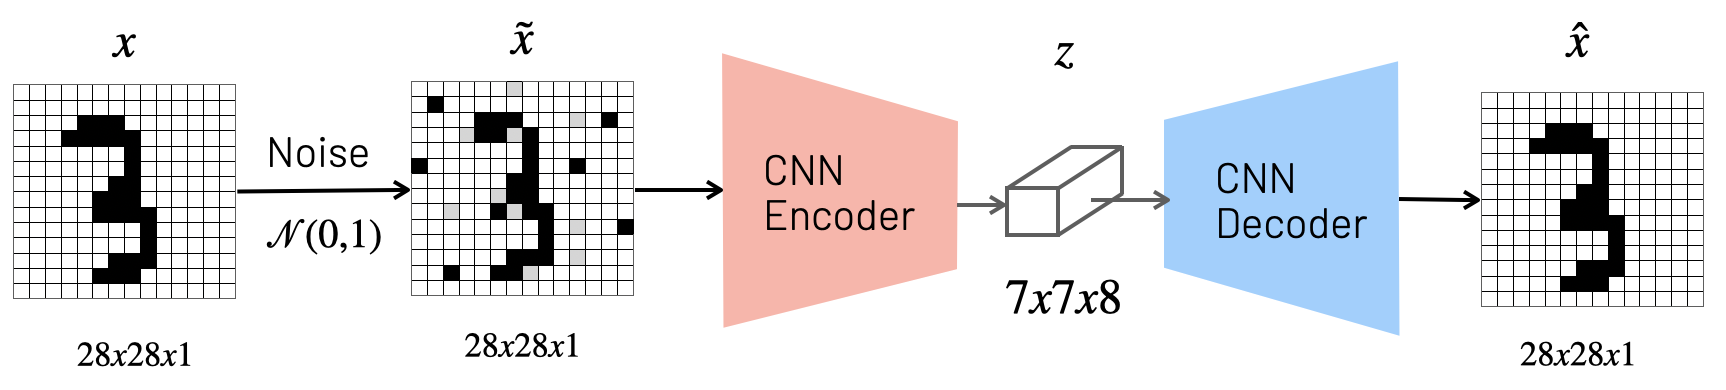

In [ ]:
# Define the Autoencoder architecture
class DenoisingAutoencoder(nn.Module):
    def __init__(self):
        super(DenoisingAutoencoder, self).__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1),  # 28x28 -> 28x28
            nn.ReLU(),
            nn.MaxPool2d(2, 2),  # 28x28 -> 14x14
            nn.Conv2d(16, 8, 3, padding=1),  # 14x14 -> 14x14
            nn.ReLU(),
            nn.MaxPool2d(2, 2)  # 14x14 -> 7x7
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(8, 16, 3, stride=2, padding=1, output_padding=1),  # 7x7 -> 14x14
            nn.ReLU(),
            nn.ConvTranspose2d(16, 8, 3, padding=1),  # 14x14 -> 14x14
            nn.ReLU(),
            nn.ConvTranspose2d(8, 1, 3, stride=2, padding=1, output_padding=1),  # 14x14 -> 28x28
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

# Data loading and preprocessing
def get_data_loaders(batch_size=128):
    transform = transforms.Compose([
        transforms.ToTensor()
    ])

    train_dataset = datasets.MNIST('./data', train=True, download=True, transform=transform)
    test_dataset = datasets.MNIST('./data', train=False, download=True, transform=transform)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    return train_loader, test_loader

# Add noise to images
def add_noise(images, noise_factor=0.3):
    noisy_images = images + noise_factor * torch.randn(*images.shape, device=device)
    return torch.clamp(noisy_images, 0., 1.)

# Training function
def train(model, train_loader, num_epochs=10, noise_factor=0.3):
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-3)

    model.train()
    for epoch in range(num_epochs):
        total_loss = 0
        for data, _ in train_loader:
            data = data.to(device)
            noisy_data = add_noise(data, noise_factor).to(device)

            # Forward pass
            outputs = model(noisy_data)
            loss = criterion(outputs, data)

            # Backward pass and optimize
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)
        print(f'Epoch [{epoch+1}/{num_epochs}], Average Loss: {avg_loss:.4f}')

# Visualization function
def visualize_results(model, test_loader, noise_factor=0.3, num_images=5):
    model.eval()
    with torch.no_grad():
        data, _ = next(iter(test_loader))
        data = data[:num_images].to(device)
        noisy_data = add_noise(data, noise_factor).to(device)
        reconstructed = model(noisy_data)

        # Plot the results
        plt.figure(figsize=(12, 4))
        for i in range(num_images):
            # Original image
            plt.subplot(3, num_images, i + 1)
            plt.imshow(data[i].cpu().squeeze(), cmap='gray')
            plt.axis('off')
            if i == 0:
                plt.title('Original')

            # Noisy image
            plt.subplot(3, num_images, i + 1 + num_images)
            plt.imshow(noisy_data[i].cpu().squeeze(), cmap='gray')
            plt.axis('off')
            if i == 0:
                plt.title('Noisy')

            # Reconstructed image
            plt.subplot(3, num_images, i + 1 + 2*num_images)
            plt.imshow(reconstructed[i].cpu().squeeze(), cmap='gray')
            plt.axis('off')
            if i == 0:
                plt.title('Reconstructed')

        plt.tight_layout()
        plt.show()

In [ ]:
    # Hyperparameters
    batch_size = 128
    num_epochs = 10
    noise_factor = 0.3

    # Get data loaders
    train_loader, test_loader = get_data_loaders(batch_size)

    # Initialize model
    model = DenoisingAutoencoder().to(device)

    # Train the model
    train(model, train_loader, num_epochs, noise_factor)

100%|██████████| 9.91M/9.91M [00:00<00:00, 17.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 483kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.46MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.04MB/s]


Epoch [1/10], Average Loss: 0.0977
Epoch [2/10], Average Loss: 0.0141
Epoch [3/10], Average Loss: 0.0104
Epoch [4/10], Average Loss: 0.0093
Epoch [5/10], Average Loss: 0.0087
Epoch [6/10], Average Loss: 0.0083
Epoch [7/10], Average Loss: 0.0080
Epoch [8/10], Average Loss: 0.0078
Epoch [9/10], Average Loss: 0.0076
Epoch [10/10], Average Loss: 0.0075


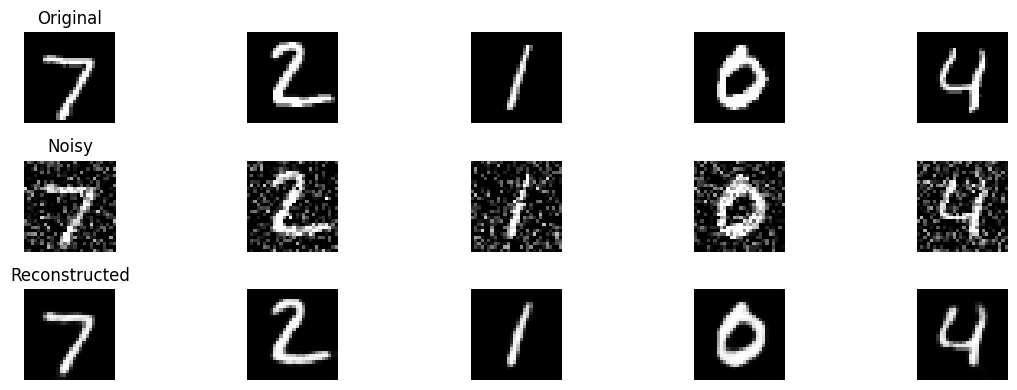

In [ ]:
# Visualize results
visualize_results(model, test_loader, noise_factor)

In [ ]:
def visualize_latent_space(model, test_loader, device):
    # Get bottleneck representations
    features = []
    labels = []
    model.eval()

    with torch.no_grad():
        for data, label in test_loader:
            data = data.to(device)
            # Get encoder output
            encoded = model.encoder(data)
            # Reshape: [batch_size, channels, height, width] -> [batch_size, flattened_features]
            encoded = encoded.view(encoded.size(0), -1)
            features.append(encoded.cpu().numpy())
            labels.append(label.numpy())

    features = np.concatenate(features)
    labels = np.concatenate(labels)

    # Reduce to 2D using t-SNE
    tsne = TSNE(n_components=2, random_state=42)
    features_2d = tsne.fit_transform(features)

    # Plot
    plt.figure(figsize=(10, 10))
    scatter = plt.scatter(features_2d[:, 0], features_2d[:, 1],
                         c=labels, cmap='tab10', alpha=0.6)
    plt.colorbar(scatter)
    plt.title('Denoising Autoencoder Latent Space (t-SNE)')
    plt.xlabel('First Component')
    plt.ylabel('Second Component')
    plt.show()

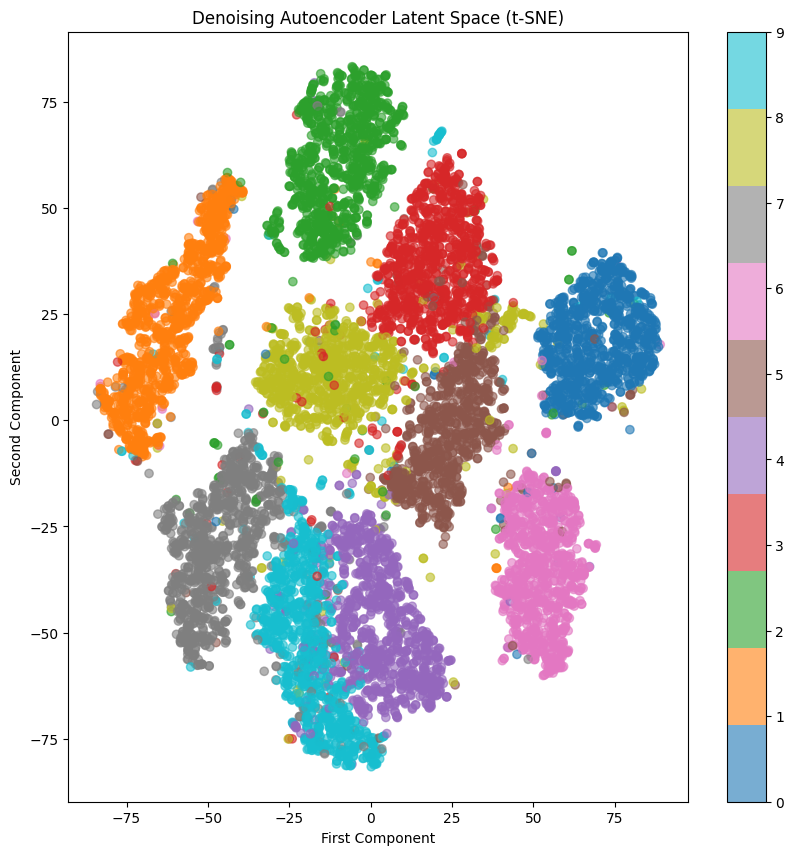

In [ ]:
visualize_latent_space(model, test_loader, device)

# Variational Autoencoder

In [ ]:
class VAE(nn.Module):
    def __init__(self, latent_dim=2):
        super(VAE, self).__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, 3, stride=1, padding=1),  # 28x28
            nn.ReLU(),
            nn.Conv2d(32, 64, 3, stride=2, padding=1),  # 14x14
            nn.ReLU(),
            nn.Conv2d(64, 128, 3, stride=2, padding=1),  # 7x7
            nn.ReLU(),
            nn.Flatten()
        )

        # Latent space
        self.fc_mu = nn.Linear(128 * 7 * 7, latent_dim)
        self.fc_var = nn.Linear(128 * 7 * 7, latent_dim)

        # Decoder
        self.decoder_input = nn.Linear(latent_dim, 128 * 7 * 7)

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 3, stride=2, padding=1, output_padding=1),  # 14x14
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 3, stride=2, padding=1, output_padding=1),  # 28x28
            nn.ReLU(),
            nn.Conv2d(32, 1, 3, stride=1, padding=1),  # 28x28
            nn.Sigmoid()
        )

    def encode(self, x):
        x = self.encoder(x)
        mu = self.fc_mu(x)
        log_var = self.fc_var(x)
        return mu, log_var

    def sample(self, mu, log_var):
        # Sample with reparametrization trick to allow backpropagation
        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        z = self.decoder_input(z)
        z = z.view(-1, 128, 7, 7)
        return self.decoder(z)

    def forward(self, x):
        mu, log_var = self.encode(x)
        z = self.sample(mu, log_var)
        return self.decode(z), mu, log_var

In [ ]:
def loss_function(recon_x, x, mu, log_var):
    MSE = F.mse_loss(recon_x, x, reduction='sum') / x.size(0)  # Average over batch
    KLD = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp()) / x.size(0)
    return MSE + KLD

def train_vae(vae, train_loader, epochs=10):
    optimizer = torch.optim.Adam(vae.parameters(), lr=1e-3)

    vae.train()
    for epoch in range(epochs):
        total_loss = 0
        for batch_idx, (data, _) in enumerate(train_loader):
            data = data.to(device)
            optimizer.zero_grad()

            recon_batch, mu, log_var = vae(data)
            loss = loss_function(recon_batch, data, mu, log_var)

            loss.backward()
            total_loss += loss.item()
            optimizer.step()

        print(f'Epoch {epoch+1}, Average loss: {total_loss / len(train_loader.dataset):.4f}')


In [ ]:
# Setup and training
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
transform = transforms.Compose([transforms.ToTensor()])

train_dataset = datasets.MNIST('./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST('./data', train=False, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

vae = VAE(latent_dim=2).to(device)
train_vae(vae, train_loader, epochs=10)

Epoch 1, Average loss: 0.4015
Epoch 2, Average loss: 0.3334
Epoch 3, Average loss: 0.3215
Epoch 4, Average loss: 0.3149
Epoch 5, Average loss: 0.3102
Epoch 6, Average loss: 0.3067
Epoch 7, Average loss: 0.3037
Epoch 8, Average loss: 0.3014
Epoch 9, Average loss: 0.2995
Epoch 10, Average loss: 0.2977


In [ ]:
def visualize_latent_space(vae, test_loader, device):
    vae.eval()
    z_points = []
    labels = []

    with torch.no_grad():
        for data, label in test_loader:
            data = data.to(device)
            mu, _ = vae.encode(data)
            z_points.append(mu.cpu().numpy())
            labels.append(label.numpy())

    z_points = np.concatenate(z_points, axis=0)
    labels = np.concatenate(labels, axis=0)

    plt.figure(figsize=(10, 10))
    scatter = plt.scatter(z_points[:, 0], z_points[:, 1], c=labels, cmap='tab10')
    plt.colorbar(scatter)
    plt.title('VAE Latent Space (Direct 2D Projection)')
    plt.xlabel('z₁')
    plt.ylabel('z₂')
    plt.show()



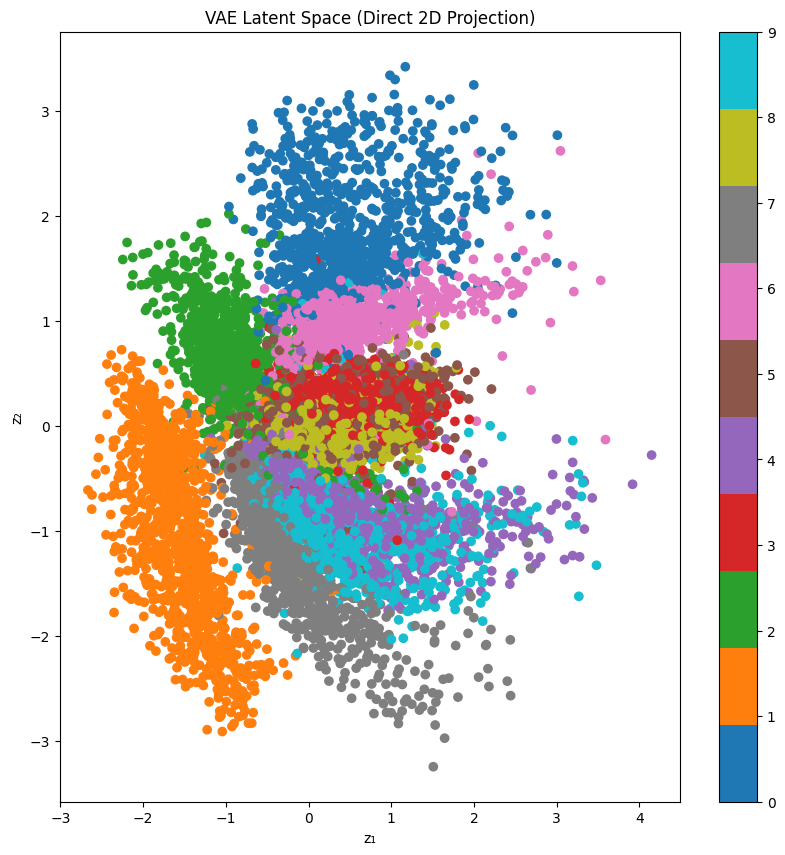

In [ ]:
# Visualize results
visualize_latent_space(vae, test_loader, device)

In [ ]:
def interpolate_digits(vae, test_loader, device):
    vae.eval()
    # Get two random digits
    data, labels = next(iter(test_loader))
    data = data.to(device)

    with torch.no_grad():
        # Get latent representations
        mu1, _ = vae.encode(data[0:1])
        mu2, _ = vae.encode(data[1:2])

        # Create interpolation points
        alphas = np.linspace(0, 1, 10)
        interp_latent = []

        for alpha in alphas:
            z = alpha * mu1 + (1 - alpha) * mu2
            interp_latent.append(vae.decode(z))

    # Plot interpolation
    plt.figure(figsize=(15, 3))
    for i, img in enumerate(interp_latent):
        plt.subplot(1, 10, i+1)
        plt.imshow(img.cpu().squeeze(), cmap='gray')
        plt.axis('off')
    plt.suptitle('Latent Space Interpolation')
    plt.show()

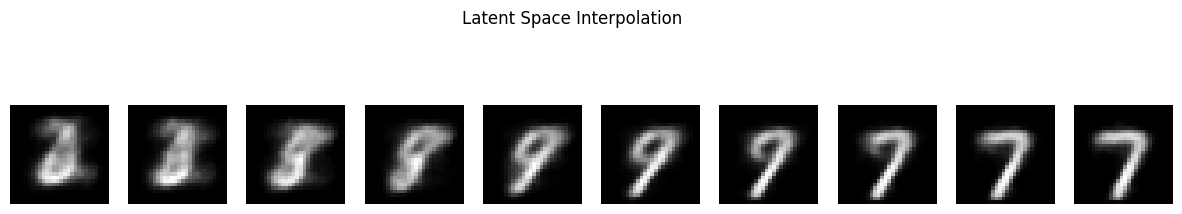

In [ ]:
interpolate_digits(vae, test_loader, device)